# 日経平均株価 15分足

In [1]:
import sys

path_up = ".."
if not path_up in sys.path:
    sys.path.append(path_up)

In [2]:
import datetime

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import mplfinance as mpf
import numpy as np
import pandas as pd
import yfinance as yf

from funcs.commons import get_name_15min_chart, get_name_15min_chart_usd

In [3]:
code = "N225"
symbol = f"^{code}"
yticker = yf.Ticker(symbol)
df = yticker.history(period="1d", interval="15m")
df

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2026-04-24 09:00:00+09:00,59407.441406,59561.460938,59225.371094,59561.460938,0,0.0,0.0
2026-04-24 09:15:00+09:00,59566.140625,59625.261719,59480.058594,59612.570312,0,0.0,0.0
2026-04-24 09:30:00+09:00,59620.429688,59687.000000,59456.531250,59494.320312,0,0.0,0.0
2026-04-24 09:45:00+09:00,59487.378906,59533.468750,59422.738281,59507.089844,0,0.0,0.0
2026-04-24 10:00:00+09:00,59516.640625,59518.890625,59345.500000,59381.269531,0,0.0,0.0
2026-04-24 10:15:00+09:00,59382.320312,59558.859375,59322.050781,59543.671875,0,0.0,0.0
2026-04-24 10:30:00+09:00,59547.191406,59566.839844,59383.890625,59444.160156,0,0.0,0.0
2026-04-24 10:45:00+09:00,59448.500000,59565.468750,59425.859375,59538.308594,0,0.0,0.0
2026-04-24 11:00:00+09:00,59528.820312,59538.031250,59369.460938,59413.531250,0,0.0,0.0


In [4]:
dt_start = df.index[0]
dt_end = pd.to_datetime(
    f"{dt_start.year:04d}-{dt_start.month:02d}-{dt_start.day:02d} 15:30:00+09:00"
).tz_convert("Asia/Tokyo")
dt_start, dt_end

(Timestamp('2026-04-24 09:00:00+0900', tz='Asia/Tokyo'),
 Timestamp('2026-04-24 15:30:00+0900', tz='Asia/Tokyo'))

In [5]:
# 過去一週間のデータを取得
td = datetime.timedelta(days=7)
dt_first = df.index[0]
dt_prev = dt_first - td
df_last = yticker.history(interval="1d", start=str(dt_prev.date()))
print(df_last["Close"])
n = len(df_last)
lastclose = df_last[n - 2 : n - 1]["Close"].iloc[0]
# lastclose = 56308.42  # 4/8 終値
# 確認のため出力
df_last[n - 2 : n - 1]["Close"]

Date
2026-04-17 00:00:00+09:00    58475.898438
2026-04-20 00:00:00+09:00    58824.890625
2026-04-21 00:00:00+09:00    59349.171875
2026-04-22 00:00:00+09:00    59585.859375
2026-04-23 00:00:00+09:00    59140.230469
2026-04-24 00:00:00+09:00    59343.398438
Name: Close, dtype: float64


Date
2026-04-23 00:00:00+09:00    59140.230469
Name: Close, dtype: float64

In [6]:
delta_open = df.head(1)["Open"].iloc[0] - lastclose
print(f"{delta_open:+.2f}")

+267.21


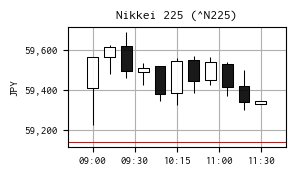

In [7]:
FONT_PATH = "../fonts/RictyDiminished-Regular.ttf"
fm.fontManager.addfont(FONT_PATH)

# FontPropertiesオブジェクト生成（名前の取得のため）
font_prop = fm.FontProperties(fname=FONT_PATH)
font_prop.get_name()

plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["font.size"] = 8

fig, ax = plt.subplots(figsize=(3, 1.8))

ax.axhline(y=lastclose, color="red", linewidth=0.75)
mpf.plot(
    df,
    type="candle",
    style="default",
    datetime_format="%H:%M",
    xrotation=0,
    update_width_config=dict(candle_linewidth=0.75),
    ax=ax,
)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
ax.set_ylabel("JPY")
ax.grid()

if "shortName" in yticker.info:
    ax.set_title(f"{yticker.info['shortName']} ({symbol})")
elif "longName" in yticker.info:
    ax.set_title(f"{yticker.info['longName']} ({symbol})")
else:
    ax.set_title(f"{symbol}")

plt.tight_layout()
plt.savefig(get_name_15min_chart(code, dt_first))
plt.show()

In [8]:
code2 = "USDJPY=X"
symbol2 = code2
ticker2 = yf.Ticker(symbol2)

In [9]:
# 15分足で過去 2 日分のデータを取得
df_exchange = ticker2.history(period="2d", interval="15m")
df_exchange.index = df_exchange.index.tz_convert("Asia/Tokyo")
df_exchange

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2026-04-23 08:00:00+09:00,159.464005,159.494995,159.451004,159.459000,0,0.0,0.0
2026-04-23 08:15:00+09:00,159.460007,159.466995,159.429001,159.451004,0,0.0,0.0
2026-04-23 08:30:00+09:00,159.455994,159.494003,159.449997,159.466003,0,0.0,0.0
2026-04-23 08:45:00+09:00,159.472000,159.494995,159.453995,159.488998,0,0.0,0.0
2026-04-23 09:00:00+09:00,159.488998,159.600006,159.451004,159.589005,0,0.0,0.0
...,...,...,...,...,...,...,...
2026-04-24 10:45:00+09:00,159.785995,159.794006,159.746994,159.751007,0,0.0,0.0
2026-04-24 11:00:00+09:00,159.751007,159.792007,159.746994,159.774994,0,0.0,0.0
2026-04-24 11:15:00+09:00,159.774002,159.796997,159.764999,159.783005,0,0.0,0.0


In [10]:
ser_rate = df_exchange.loc[df.index, "Close"]
ser_rate
df2 = pd.DataFrame()
df2["Open"] = df["Open"] / ser_rate
df2["High"] = df["High"] / ser_rate
df2["Low"] = df["Low"] / ser_rate
df2["Close"] = df["Close"] / ser_rate
df2

,Open,High,Low,Close
Datetime,,,,
2026-04-24 09:00:00+09:00,371.924141,372.888390,370.784278,372.888390
2026-04-24 09:15:00+09:00,373.004096,373.374314,372.465049,373.294840
2026-04-24 09:30:00+09:00,373.208475,373.625188,372.182513,372.419063
2026-04-24 09:45:00+09:00,372.294072,372.582519,371.889527,372.417430
2026-04-24 10:00:00+09:00,372.470196,372.484277,371.399154,371.623009
2026-04-24 10:15:00+09:00,371.634234,372.739074,371.257047,372.644026
2026-04-24 10:30:00+09:00,372.682387,372.805359,371.660352,372.037555
2026-04-24 10:45:00+09:00,372.132239,372.864433,371.990515,372.694418
2026-04-24 11:00:00+09:00,372.579080,372.636730,371.581682,371.857509


In [11]:
dt = df_exchange.head(1).index[0]
dt_last_close = pd.to_datetime(f"{str(dt.date())} 15:15:00+09:00")
print(dt_last_close)
last_close_usd = df_exchange.loc[dt_last_close, "Close"]
last_close_usd

2026-04-23 15:15:00+09:00


np.float64(159.6020050048828)

前日終値（ドル換算） 370.5481674051694


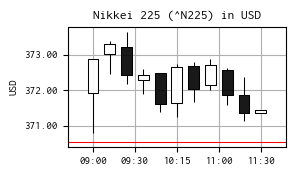

In [12]:
FONT_PATH = "../fonts/RictyDiminished-Regular.ttf"
fm.fontManager.addfont(FONT_PATH)

# FontPropertiesオブジェクト生成（名前の取得のため）
font_prop = fm.FontProperties(fname=FONT_PATH)
font_prop.get_name()

plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["font.size"] = 8

fig, ax = plt.subplots(figsize=(3, 1.8))

ax.axhline(y=lastclose / last_close_usd, color="red", linewidth=0.75)
print("前日終値（ドル換算）", lastclose / last_close_usd)
mpf.plot(
    df2,
    type="candle",
    style="default",
    datetime_format="%H:%M",
    xrotation=0,
    update_width_config=dict(candle_linewidth=0.75),
    ax=ax,
)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.2f}"))
ax.set_ylabel("USD")
ax.grid()

if "shortName" in yticker.info:
    ax.set_title(f"{yticker.info['shortName']} ({symbol}) in USD")
elif "longName" in yticker.info:
    ax.set_title(f"{yticker.info['longName']} ({symbol}) in USD")
else:
    ax.set_title(f"{symbol}")

plt.tight_layout()
plt.savefig(get_name_15min_chart_usd(code, dt_first))
plt.show()